In [ ]:
!pip install torch torchvision datasets

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import random

# Fix random seeds for reproducibility (rubric requirement)
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from datasets import load_dataset
dataset = load_dataset("garythung/trashnet")

README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

dataset-original.zip: reconstructing file:   0%|          |  0.00B / 3.63GB            

dataset-original.zip: downloading bytes:           |  0.00B            

dataset-resized.zip: reconstructing file:   0%|          |  0.00B / 42.8MB            

dataset-resized.zip: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5054 [00:00<?, ? examples/s]

DatasetGenerationError: An error occurred while generating the dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("garythung/trashnet", download_mode="force_redownload")

dataset-original.zip: reconstructing file:   0%|          |  0.00B / 3.63GB            

dataset-original.zip: downloading bytes:           |  0.00B            

dataset-resized.zip: reconstructing file:   0%|          |  0.00B / 42.8MB            

dataset-resized.zip: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5054 [00:00<?, ? examples/s]

DatasetGenerationError: An error occurred while generating the dataset

In [ ]:
!pip install datasets==2.19.0

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 12.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.12.0
    Uninstalling fsspec-2025.12.0:
      Successfully uninstalled fsspec-2025.12.0
  Attempting uninstall: dill
    Found existing installation: dill 0.4.1
    Uninstalling dill-0.4.1:
      Successfully uninstalled dill-0.4.1
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.19
    Uninstalling multiprocess-0.70.19:
      Successfully uninstalled multiprocess-0.70.19
  Attempting uninstall: datasets
    F

In [ ]:
!pip install datasets==2.19.0

In [ ]:
from datasets import load_dataset
dataset = load_dataset("garythung/trashnet")

Generating train split:   0%|          | 0/5054 [00:00<?, ? examples/s]

In [ ]:
split_dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_val = split_dataset["train"]
test_data = split_dataset["test"]

train_val_split = train_val.train_test_split(test_size=0.1, seed=42)
train_data = train_val_split["train"]
val_data = train_val_split["test"]

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 3638
Validation: 405
Test: 1011


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class TrashDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        example = self.hf_dataset[idx]
        image = example["image"].convert("RGB")
        label = example["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
import torchvision.transforms as transforms

IMG_SIZE = 224

# Standard ImageNet normalization values (needed for pretrained models later)
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

# Basic transform (no augmentation) - used for val/test, and for Approach 1 baseline
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataset = TrashDataset(train_data, transform=basic_transform)
val_dataset = TrashDataset(val_data, transform=basic_transform)
test_dataset = TrashDataset(test_data, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("PyTorch data loaders ready")

PyTorch data loaders ready


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        # After 3 pooling layers: 224 -> 112 -> 56 -> 28
        self.fc1 = nn.Linear(128 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model_cnn = SimpleCNN(num_classes=6).to(device)
print(model_cnn)

NameError: name 'device' is not defined

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

NameError: name 'torch' is not defined

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from datasets import load_dataset
dataset = load_dataset("garythung/trashnet")

In [ ]:
split_dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_val = split_dataset["train"]
test_data = split_dataset["test"]

train_val_split = train_val.train_test_split(test_size=0.1, seed=42)
train_data = train_val_split["train"]
val_data = train_val_split["test"]

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 3638
Validation: 405
Test: 1011


In [ ]:
from PIL import Image

class TrashDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        example = self.hf_dataset[idx]
        image = example["image"].convert("RGB")
        label = example["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
IMG_SIZE = 224

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])

In [ ]:
BATCH_SIZE = 32

train_dataset = TrashDataset(train_data, transform=basic_transform)
val_dataset = TrashDataset(val_data, transform=basic_transform)
test_dataset = TrashDataset(test_data, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("PyTorch data loaders ready")

PyTorch data loaders ready


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model_cnn = SimpleCNN(num_classes=6).to(device)
print(model_cnn)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)


In [ ]:
total_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 12,939,206


In [ ]:
import time

def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time:.1f} seconds")
    return history, training_time

history_cnn, time_cnn = train_model(model_cnn, train_loader, val_loader, epochs=10)

KeyboardInterrupt: 

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
!pip install tqdm

In [ ]:
from tqdm import tqdm
import time

def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time:.1f} seconds")
    return history, training_time

In [ ]:
history_cnn, time_cnn = train_model(model_cnn, train_loader, val_loader, epochs=10)

Epoch 1/10: 100%|██████████| 114/114 [07:04<00:00,  3.73s/it, loss=0.954]


Epoch 1/10 - train_loss: 1.0475 - train_acc: 0.6056 - val_loss: 1.0149 - val_acc: 0.6173


Epoch 2/10: 100%|██████████| 114/114 [07:07<00:00,  3.75s/it, loss=0.763]


Epoch 2/10 - train_loss: 0.7784 - train_acc: 0.7150 - val_loss: 0.8194 - val_acc: 0.7037


Epoch 3/10: 100%|██████████| 114/114 [07:06<00:00,  3.74s/it, loss=0.804]


...

Epoch 8/10 - train_loss: 0.1005 - train_acc: 0.9670 - val_loss: 1.3456 - val_acc: 0.6988


Epoch 9/10: 100%|██████████| 114/114 [07:05<00:00,  3.73s/it, loss=0.164]


Epoch 9/10 - train_loss: 0.0692 - train_acc: 0.9777 - val_loss: 1.3558 - val_acc: 0.7235


Epoch 10/10: 100%|██████████| 114/114 [07:06<00:00,  3.74s/it, loss=0.0348]


Epoch 10/10 - train_loss: 0.0654 - train_acc: 0.9835 - val_loss: 1.2328 - val_acc: 0.7407

Training completed in 4734.8 seconds


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    print(f"Test accuracy: {accuracy:.4f}")
    return accuracy

test_acc_cnn = evaluate_model(model_cnn, test_loader)

Test accuracy: 0.7557


In [ ]:
torch.save(model_cnn.state_dict(), "approach1_cnn_scratch.pth")
print("Approach 1 model saved")

Approach 1 model saved


In [ ]:
import json

with open("history_cnn.json", "w") as f:
    json.dump({
        "history": history_cnn,
        "test_accuracy": test_acc_cnn,
        "training_time_seconds": time_cnn,
        "trainable_params": total_params
    }, f)
print("History saved")

History saved


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

shutil.copy("approach1_cnn_scratch.pth", "/content/drive/MyDrive/approach1_cnn_scratch.pth")
shutil.copy("history_cnn.json", "/content/drive/MyDrive/history_cnn.json")

print("Approach 1 files saved to Drive")

Approach 1 files saved to Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print(device)
print(len(train_loader.dataset))

NameError: name 'device' is not defined

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import random
from PIL import Image
import time, json

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from datasets import load_dataset
dataset = load_dataset("garythung/trashnet")

README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

dataset-original.zip: reconstructing file:   0%|          |  0.00B / 3.63GB            

dataset-original.zip: downloading bytes:           |  0.00B            

dataset-resized.zip: reconstructing file:   0%|          |  0.00B / 42.8MB            

dataset-resized.zip: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5054 [00:00<?, ? examples/s]

DatasetGenerationError: An error occurred while generating the dataset

In [ ]:
!pip install datasets==2.19.0

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 15.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.12.0
    Uninstalling fsspec-2025.12.0:
      Successfully uninstalled fsspec-2025.12.0
  Attempting uninstall: dill
    Found existing installation: dill 0.4.1
    Uninstalling dill-0.4.1:
      Successfully uninstalled dill-0.4.1
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.19
    Uninstalling multiprocess-0.70.19:
      Successfully uninstalled multiprocess-0.70.19
  Attempting uninstall: datasets
    

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import random
from PIL import Image
import time, json
from datasets import load_dataset

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset = load_dataset("garythung/trashnet")

split_dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_val = split_dataset["train"]
test_data = split_dataset["test"]

train_val_split = train_val.train_test_split(test_size=0.1, seed=42)
train_data = train_val_split["train"]
val_data = train_val_split["test"]

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

class TrashDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        example = self.hf_dataset[idx]
        image = example["image"].convert("RGB")
        label = example["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

IMG_SIZE = 224
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])

BATCH_SIZE = 32
train_dataset = TrashDataset(train_data, transform=basic_transform)
val_dataset = TrashDataset(val_data, transform=basic_transform)
test_dataset = TrashDataset(test_data, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("PyTorch data loaders ready")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import random
from PIL import Image
import time, json
from datasets import load_dataset

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset = load_dataset("garythung/trashnet")

split_dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_val = split_dataset["train"]
test_data = split_dataset["test"]

train_val_split = train_val.train_test_split(test_size=0.1, seed=42)
train_data = train_val_split["train"]
val_data = train_val_split["test"]

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

class TrashDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        example = self.hf_dataset[idx]
        image = example["image"].convert("RGB")
        label = example["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

IMG_SIZE = 224
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])

BATCH_SIZE = 32
train_dataset = TrashDataset(train_data, transform=basic_transform)
val_dataset = TrashDataset(val_data, transform=basic_transform)
test_dataset = TrashDataset(test_data, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("PyTorch data loaders ready")

In [ ]:
print("Device:", device)
print("Train size:", len(train_data))

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import random
from PIL import Image
import time, json
from datasets import load_dataset

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset = load_dataset("garythung/trashnet")

split_dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_val = split_dataset["train"]
test_data = split_dataset["test"]

train_val_split = train_val.train_test_split(test_size=0.1, seed=42)
train_data = train_val_split["train"]
val_data = train_val_split["test"]

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

class TrashDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        example = self.hf_dataset[idx]
        image = example["image"].convert("RGB")
        label = example["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

IMG_SIZE = 224
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])

BATCH_SIZE = 32
train_dataset = TrashDataset(train_data, transform=basic_transform)
val_dataset = TrashDataset(val_data, transform=basic_transform)
test_dataset = TrashDataset(test_data, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("PyTorch data loaders ready")

Using device: cuda


Generating train split:   0%|          | 0/5054 [00:00<?, ? examples/s]

Train: 3638
Validation: 405
Test: 1011
PyTorch data loaders ready


In [ ]:
model_resnet_frozen = models.resnet18(weights="IMAGENET1K_V1")

for param in model_resnet_frozen.parameters():
    param.requires_grad = False

num_features = model_resnet_frozen.fc.in_features
model_resnet_frozen.fc = nn.Linear(num_features, 6)

model_resnet_frozen = model_resnet_frozen.to(device)
print(model_resnet_frozen.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 34.9MB/s]


Linear(in_features=512, out_features=6, bias=True)


In [ ]:
total_params_frozen = sum(p.numel() for p in model_resnet_frozen.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params_frozen:,}")

Total trainable parameters: 3,078


In [ ]:
from tqdm import tqdm

def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time:.1f} seconds")
    return history, training_time

In [ ]:
history_resnet_frozen, time_resnet_frozen = train_model(model_resnet_frozen, train_loader, val_loader, epochs=10)

Epoch 1/10: 100%|██████████| 114/114 [07:00<00:00,  3.69s/it, loss=0.607]


Epoch 1/10 - train_loss: 1.1078 - train_acc: 0.6047 - val_loss: 0.7266 - val_acc: 0.7481


Epoch 2/10: 100%|██████████| 114/114 [06:57<00:00,  3.66s/it, loss=0.591]


Epoch 2/10 - train_loss: 0.6797 - train_acc: 0.7779 - val_loss: 0.5863 - val_acc: 0.8148


Epoch 3/10: 100%|██████████| 114/114 [06:54<00:00,  3.64s/it, loss=0.392]


...

Epoch 8/10 - train_loss: 0.4093 - train_acc: 0.8623 - val_loss: 0.4021 - val_acc: 0.8494


Epoch 9/10: 100%|██████████| 114/114 [07:00<00:00,  3.69s/it, loss=0.715]


Epoch 9/10 - train_loss: 0.3953 - train_acc: 0.8689 - val_loss: 0.3943 - val_acc: 0.8568


Epoch 10/10: 100%|██████████| 114/114 [07:00<00:00,  3.69s/it, loss=0.204]


Epoch 10/10 - train_loss: 0.3972 - train_acc: 0.8631 - val_loss: 0.4038 - val_acc: 0.8667

Training completed in 4633.7 seconds


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    print(f"Test accuracy: {accuracy:.4f}")
    return accuracy

test_acc_resnet_frozen = evaluate_model(model_resnet_frozen, test_loader)

Test accuracy: 0.8417


In [ ]:
torch.save(model_resnet_frozen.state_dict(), "approach2_resnet_frozen.pth")

with open("history_resnet_frozen.json", "w") as f:
    json.dump({
        "history": history_resnet_frozen,
        "test_accuracy": test_acc_resnet_frozen,
        "training_time_seconds": time_resnet_frozen,
        "trainable_params": total_params_frozen
    }, f)

import shutil
shutil.copy("approach2_resnet_frozen.pth", "/content/drive/MyDrive/approach2_resnet_frozen.pth")
shutil.copy("history_resnet_frozen.json", "/content/drive/MyDrive/history_resnet_frozen.json")

print("Approach 2 files saved to Drive")

Approach 2 files saved to Drive


In [ ]:
model_resnet_finetuned = models.resnet18(weights="IMAGENET1K_V1")

# Unlike Approach 2, we do NOT freeze anything here — all layers stay trainable
num_features = model_resnet_finetuned.fc.in_features
model_resnet_finetuned.fc = nn.Linear(num_features, 6)

model_resnet_finetuned = model_resnet_finetuned.to(device)
print(model_resnet_finetuned.fc)

Linear(in_features=512, out_features=6, bias=True)


In [ ]:
total_params_finetuned = sum(p.numel() for p in model_resnet_finetuned.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params_finetuned:,}")

Total trainable parameters: 11,179,590


In [ ]:
history_resnet_finetuned, time_resnet_finetuned = train_model(
    model_resnet_finetuned,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0001  # smaller learning rate for fine-tuning
)

Epoch 1/10: 100%|██████████| 114/114 [07:07<00:00,  3.75s/it, loss=0.246]


Epoch 1/10 - train_loss: 0.5482 - train_acc: 0.8131 - val_loss: 0.2510 - val_acc: 0.9235


Epoch 2/10:  32%|███▏      | 36/114 [02:20<05:04,  3.90s/it, loss=0.0537]


KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install datasets==2.19.0

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 17.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.12.0
    Uninstalling fsspec-2025.12.0:
      Successfully uninstalled fsspec-2025.12.0
  Attempting uninstall: dill
    Found existing installation: dill 0.4.1
    Uninstalling dill-0.4.1:
      Successfully uninstalled dill-0.4.1
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.19
    Uninstalling multiprocess-0.70.19:
      Successfully uninstalled multiprocess-0.70.19
  Attempting uninstall: datasets
    F

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import random
from PIL import Image
import time, json, shutil
from tqdm import tqdm
from datasets import load_dataset

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset = load_dataset("garythung/trashnet")

split_dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_val = split_dataset["train"]
test_data = split_dataset["test"]

train_val_split = train_val.train_test_split(test_size=0.1, seed=42)
train_data = train_val_split["train"]
val_data = train_val_split["test"]

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

class TrashDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        example = self.hf_dataset[idx]
        image = example["image"].convert("RGB")
        label = example["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

IMG_SIZE = 224
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])

BATCH_SIZE = 32
train_dataset = TrashDataset(train_data, transform=basic_transform)
val_dataset = TrashDataset(val_data, transform=basic_transform)
test_dataset = TrashDataset(test_data, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("PyTorch data loaders ready")

Using device: cuda


Error while downloading from https://huggingface.co/datasets/garythung/trashnet/resolve/94cd17ebfd6702bf62281d3c89f22ff649815b46/dataset-original.zip: The read operation timed out
Trying to resume download...
Trying to resume download...


Generating train split:   0%|          | 0/5054 [00:00<?, ? examples/s]

Train: 3638
Validation: 405
Test: 1011
PyTorch data loaders ready


In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time:.1f} seconds")
    return history, training_time

def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    print(f"Test accuracy: {accuracy:.4f}")
    return accuracy

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time:.1f} seconds")
    return history, training_time

def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    print(f"Test accuracy: {accuracy:.4f}")
    return accuracy

In [ ]:
model_resnet_finetuned = models.resnet18(weights="IMAGENET1K_V1")
num_features = model_resnet_finetuned.fc.in_features
model_resnet_finetuned.fc = nn.Linear(num_features, 6)
model_resnet_finetuned = model_resnet_finetuned.to(device)

total_params_finetuned = sum(p.numel() for p in model_resnet_finetuned.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params_finetuned:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s]


Total trainable parameters: 11,179,590


In [ ]:
history_resnet_finetuned, time_resnet_finetuned = train_model(
    model_resnet_finetuned,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0001
)

Epoch 1/10: 100%|██████████| 114/114 [07:24<00:00,  3.90s/it, loss=0.136]


Epoch 1/10 - train_loss: 0.5277 - train_acc: 0.8169 - val_loss: 0.2694 - val_acc: 0.9160


Epoch 2/10: 100%|██████████| 114/114 [07:17<00:00,  3.84s/it, loss=0.131]


Epoch 2/10 - train_loss: 0.0972 - train_acc: 0.9766 - val_loss: 0.1726 - val_acc: 0.9358


Epoch 3/10: 100%|██████████| 114/114 [07:15<00:00,  3.82s/it, loss=0.0211]


...

Epoch 8/10 - train_loss: 0.0119 - train_acc: 0.9984 - val_loss: 0.1198 - val_acc: 0.9654


Epoch 9/10: 100%|██████████| 114/114 [07:17<00:00,  3.84s/it, loss=0.0715]


Epoch 9/10 - train_loss: 0.0202 - train_acc: 0.9951 - val_loss: 0.2120 - val_acc: 0.9432


Epoch 10/10: 100%|██████████| 114/114 [07:16<00:00,  3.82s/it, loss=0.0792]


Epoch 10/10 - train_loss: 0.0729 - train_acc: 0.9753 - val_loss: 0.2189 - val_acc: 0.9210

Training completed in 4867.7 seconds


In [ ]:
test_acc_resnet_finetuned = evaluate_model(model_resnet_finetuned, test_loader)

Test accuracy: 0.9209


In [ ]:
torch.save(model_resnet_finetuned.state_dict(), "approach3_resnet_finetuned.pth")

with open("history_resnet_finetuned.json", "w") as f:
    json.dump({
        "history": history_resnet_finetuned,
        "test_accuracy": test_acc_resnet_finetuned,
        "training_time_seconds": time_resnet_finetuned,
        "trainable_params": total_params_finetuned
    }, f)

shutil.copy("approach3_resnet_finetuned.pth", "/content/drive/MyDrive/approach3_resnet_finetuned.pth")
shutil.copy("history_resnet_finetuned.json", "/content/drive/MyDrive/history_resnet_finetuned.json")

print("Approach 3 files saved to Drive")

Approach 3 files saved to Drive


In [ ]:
results_summary = {
    "Approach 1: CNN from scratch": {
        "trainable_params": total_params,
        "training_time_seconds": time_cnn,
        "test_accuracy": test_acc_cnn,
        "history": history_cnn
    },
    "Approach 2: ResNet-18 frozen": {
        "trainable_params": total_params_frozen,
        "training_time_seconds": time_resnet_frozen,
        "test_accuracy": test_acc_resnet_frozen,
        "history": history_resnet_frozen
    },
    "Approach 3: ResNet-18 fine-tuned": {
        "trainable_params": total_params_finetuned,
        "training_time_seconds": time_resnet_finetuned,
        "test_accuracy": test_acc_resnet_finetuned,
        "history": history_resnet_finetuned
    }
}

for name, data in results_summary.items():
    print(f"{name}")
    print(f"  Params: {data['trainable_params']:,}")
    print(f"  Time: {data['training_time_seconds']:.1f}s ({data['training_time_seconds']/60:.1f} min)")
    print(f"  Test accuracy: {data['test_accuracy']:.4f}")
    print()

NameError: name 'total_params' is not defined

In [ ]:
with open("/content/drive/MyDrive/history_cnn.json", "r") as f:
    data1 = json.load(f)
    history_cnn = data1["history"]
    test_acc_cnn = data1["test_accuracy"]
    time_cnn = data1["training_time_seconds"]
    total_params = data1["trainable_params"]

with open("/content/drive/MyDrive/history_resnet_frozen.json", "r") as f:
    data2 = json.load(f)
    history_resnet_frozen = data2["history"]
    test_acc_resnet_frozen = data2["test_accuracy"]
    time_resnet_frozen = data2["training_time_seconds"]
    total_params_frozen = data2["trainable_params"]

print("Approach 1 and 2 results reloaded")
print("CNN test acc:", test_acc_cnn)
print("Frozen ResNet test acc:", test_acc_resnet_frozen)

Approach 1 and 2 results reloaded
CNN test acc: 0.7556874381800198
Frozen ResNet test acc: 0.8417408506429278


In [ ]:
results_summary = {
    "Approach 1: CNN from scratch": {
        "trainable_params": total_params,
        "training_time_seconds": time_cnn,
        "test_accuracy": test_acc_cnn,
        "history": history_cnn
    },
    "Approach 2: ResNet-18 frozen": {
        "trainable_params": total_params_frozen,
        "training_time_seconds": time_resnet_frozen,
        "test_accuracy": test_acc_resnet_frozen,
        "history": history_resnet_frozen
    },
    "Approach 3: ResNet-18 fine-tuned": {
        "trainable_params": total_params_finetuned,
        "training_time_seconds": time_resnet_finetuned,
        "test_accuracy": test_acc_resnet_finetuned,
        "history": history_resnet_finetuned
    }
}

for name, data in results_summary.items():
    print(f"{name}")
    print(f"  Params: {data['trainable_params']:,}")
    print(f"  Time: {data['training_time_seconds']:.1f}s ({data['training_time_seconds']/60:.1f} min)")
    print(f"  Test accuracy: {data['test_accuracy']:.4f}")
    print()

Approach 1: CNN from scratch
  Params: 12,939,206
  Time: 4734.8s (78.9 min)
  Test accuracy: 0.7557

Approach 2: ResNet-18 frozen
  Params: 3,078
  Time: 4633.7s (77.2 min)
  Test accuracy: 0.8417

Approach 3: ResNet-18 fine-tuned
  Params: 11,179,590
  Time: 4867.7s (81.1 min)
  Test accuracy: 0.9209



In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Approach": ["CNN from scratch", "ResNet-18 (frozen)", "ResNet-18 (fine-tuned)"],
    "Trainable Params": [total_params, total_params_frozen, total_params_finetuned],
    "Training Time (min)": [time_cnn/60, time_resnet_frozen/60, time_resnet_finetuned/60],
    "Test Accuracy": [test_acc_cnn, test_acc_resnet_frozen, test_acc_resnet_finetuned]
})

comparison_df.to_csv("results_comparison.csv", index=False)
shutil.copy("results_comparison.csv", "/content/drive/MyDrive/results_comparison.csv")

print(comparison_df)

                 Approach  Trainable Params  Training Time (min)  \
0        CNN from scratch          12939206            78.913628   
1      ResNet-18 (frozen)              3078            77.229005   
2  ResNet-18 (fine-tuned)          11179590            81.127703   

   Test Accuracy  
0       0.755687  
1       0.841741  
2       0.920870  


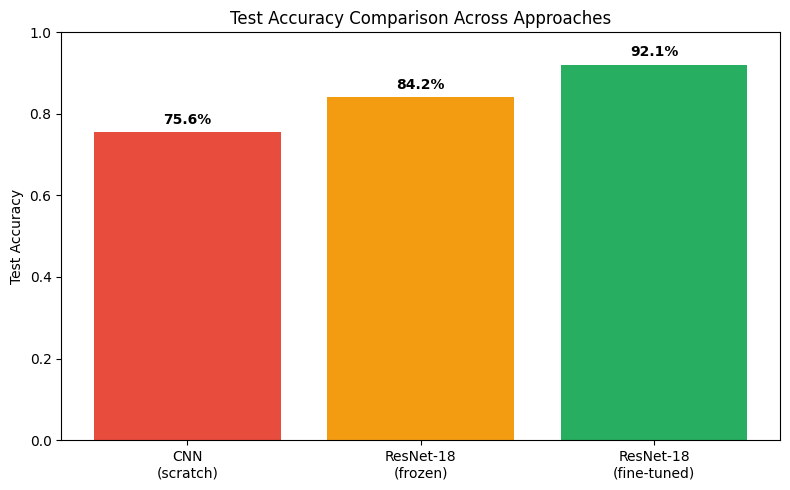

In [ ]:
import matplotlib.pyplot as plt

approaches = ["CNN\n(scratch)", "ResNet-18\n(frozen)", "ResNet-18\n(fine-tuned)"]
accuracies = [test_acc_cnn, test_acc_resnet_frozen, test_acc_resnet_finetuned]

plt.figure(figsize=(8, 5))
bars = plt.bar(approaches, accuracies, color=["#e74c3c", "#f39c12", "#27ae60"])
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison Across Approaches")
plt.ylim(0, 1)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
              f"{acc:.1%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("chart_accuracy_comparison.png", dpi=150)
plt.show()

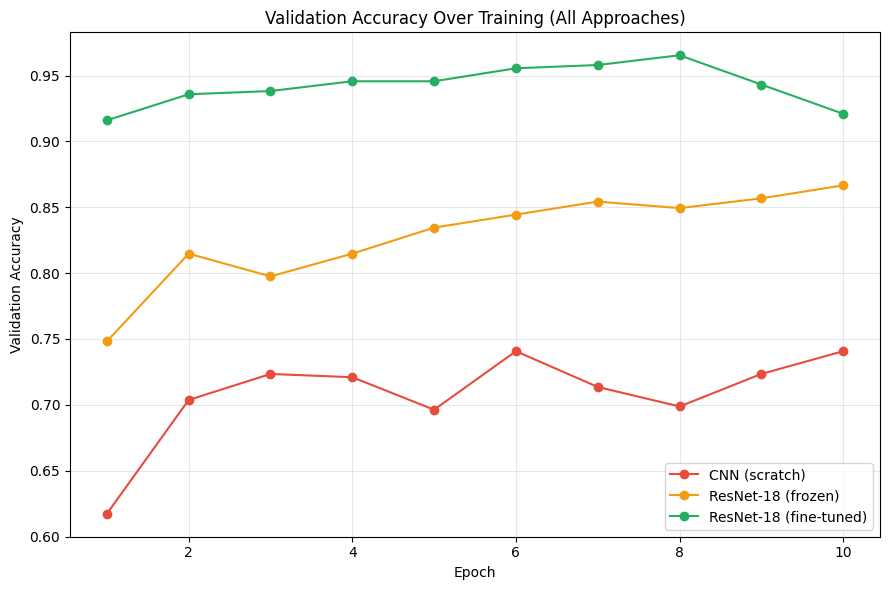

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(range(1, 11), history_cnn["val_acc"], marker='o', label="CNN (scratch)", color="#e74c3c")
plt.plot(range(1, 11), history_resnet_frozen["val_acc"], marker='o', label="ResNet-18 (frozen)", color="#f39c12")
plt.plot(range(1, 11), history_resnet_finetuned["val_acc"], marker='o', label="ResNet-18 (fine-tuned)", color="#27ae60")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Over Training (All Approaches)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart_learning_curves.png", dpi=150)
plt.show()

In [ ]:
shutil.copy("chart_accuracy_comparison.png", "/content/drive/MyDrive/chart_accuracy_comparison.png")
shutil.copy("chart_learning_curves.png", "/content/drive/MyDrive/chart_learning_curves.png")
print("Charts saved to Drive")

Charts saved to Drive


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

label_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return all_labels, all_preds

# Get predictions for all three models on the test set
labels_cnn, preds_cnn = get_predictions(model_cnn, test_loader)

NameError: name 'model_cnn' is not defined

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
model_cnn = SimpleCNN(num_classes=6).to(device)
model_cnn.load_state_dict(torch.load("/content/drive/MyDrive/approach1_cnn_scratch.pth"))

model_resnet_frozen = models.resnet18(weights=None)
model_resnet_frozen.fc = nn.Linear(model_resnet_frozen.fc.in_features, 6)
model_resnet_frozen.load_state_dict(torch.load("/content/drive/MyDrive/approach2_resnet_frozen.pth"))
model_resnet_frozen = model_resnet_frozen.to(device)

print("Approach 1 and 2 models reloaded")

Approach 1 and 2 models reloaded


In [ ]:
label_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return all_labels, all_preds

labels_cnn, preds_cnn = get_predictions(model_cnn, test_loader)
labels_frozen, preds_frozen = get_predictions(model_resnet_frozen, test_loader)
labels_finetuned, preds_finetuned = get_predictions(model_resnet_finetuned, test_loader)

print("All predictions gathered")

All predictions gathered


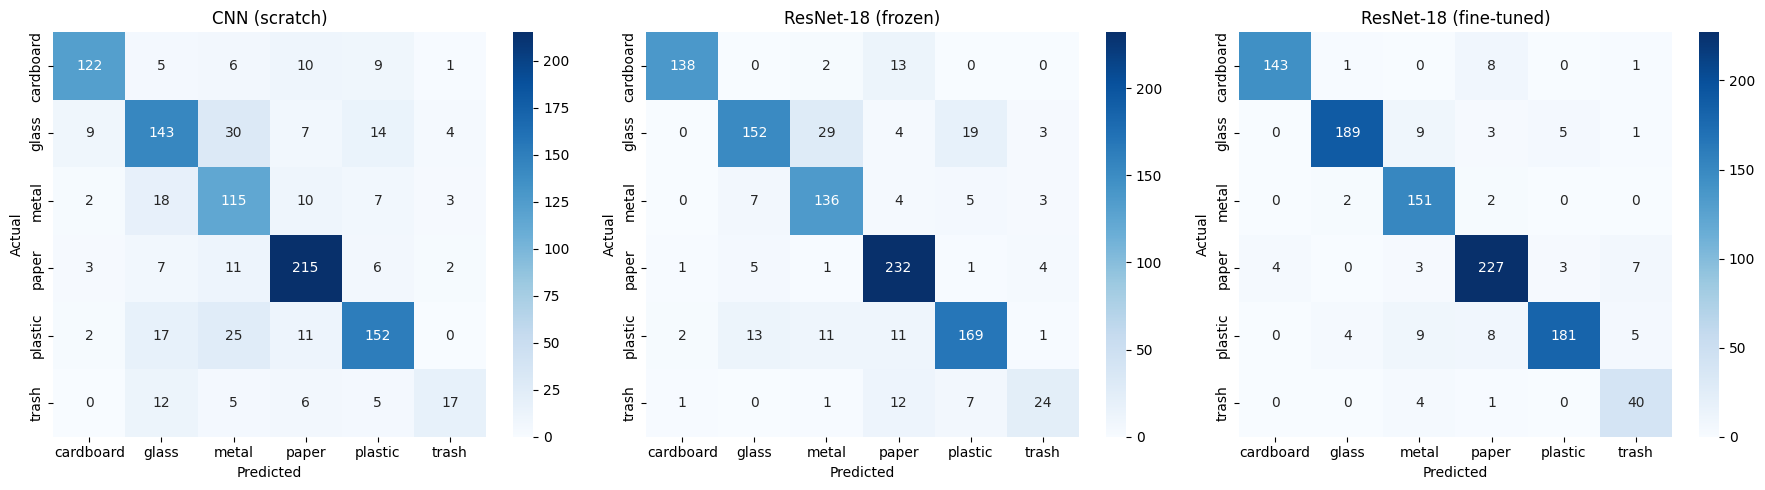

Confusion matrices saved


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_data = [
    ("CNN (scratch)", labels_cnn, preds_cnn),
    ("ResNet-18 (frozen)", labels_frozen, preds_frozen),
    ("ResNet-18 (fine-tuned)", labels_finetuned, preds_finetuned)
]

for ax, (title, labels, preds) in zip(axes, models_data):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("chart_confusion_matrices.png", dpi=150)
plt.show()

shutil.copy("chart_confusion_matrices.png", "/content/drive/MyDrive/chart_confusion_matrices.png")
print("Confusion matrices saved")

In [1]:
import os
for f in ["approach1_cnn_scratch.pth", "approach2_resnet_frozen.pth", "approach3_resnet_finetuned.pth"]:
    path = f"/content/drive/MyDrive/{f}"
    size_mb = os.path.getsize(path) / (1024*1024)
    print(f"{f}: {size_mb:.1f} MB")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/approach1_cnn_scratch.pth'

In [2]:
import os
for f in ["approach1_cnn_scratch.pth", "approach2_resnet_frozen.pth", "approach3_resnet_finetuned.pth"]:
    path = f"/content/drive/MyDrive/{f}"
    size_mb = os.path.getsize(path) / (1024*1024)
    print(f"{f}: {size_mb:.1f} MB")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/approach1_cnn_scratch.pth'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
for f in ["approach1_cnn_scratch.pth", "approach2_resnet_frozen.pth", "approach3_resnet_finetuned.pth"]:
    path = f"/content/drive/MyDrive/{f}"
    size_mb = os.path.getsize(path) / (1024*1024)
    print(f"{f}: {size_mb:.1f} MB")

approach1_cnn_scratch.pth: 49.4 MB
approach2_resnet_frozen.pth: 42.7 MB
approach3_resnet_finetuned.pth: 42.7 MB
